<a href="https://colab.research.google.com/github/emcgeever-husky/Econ3916/blob/main/Lab_15/From_Regression_to_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [39]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


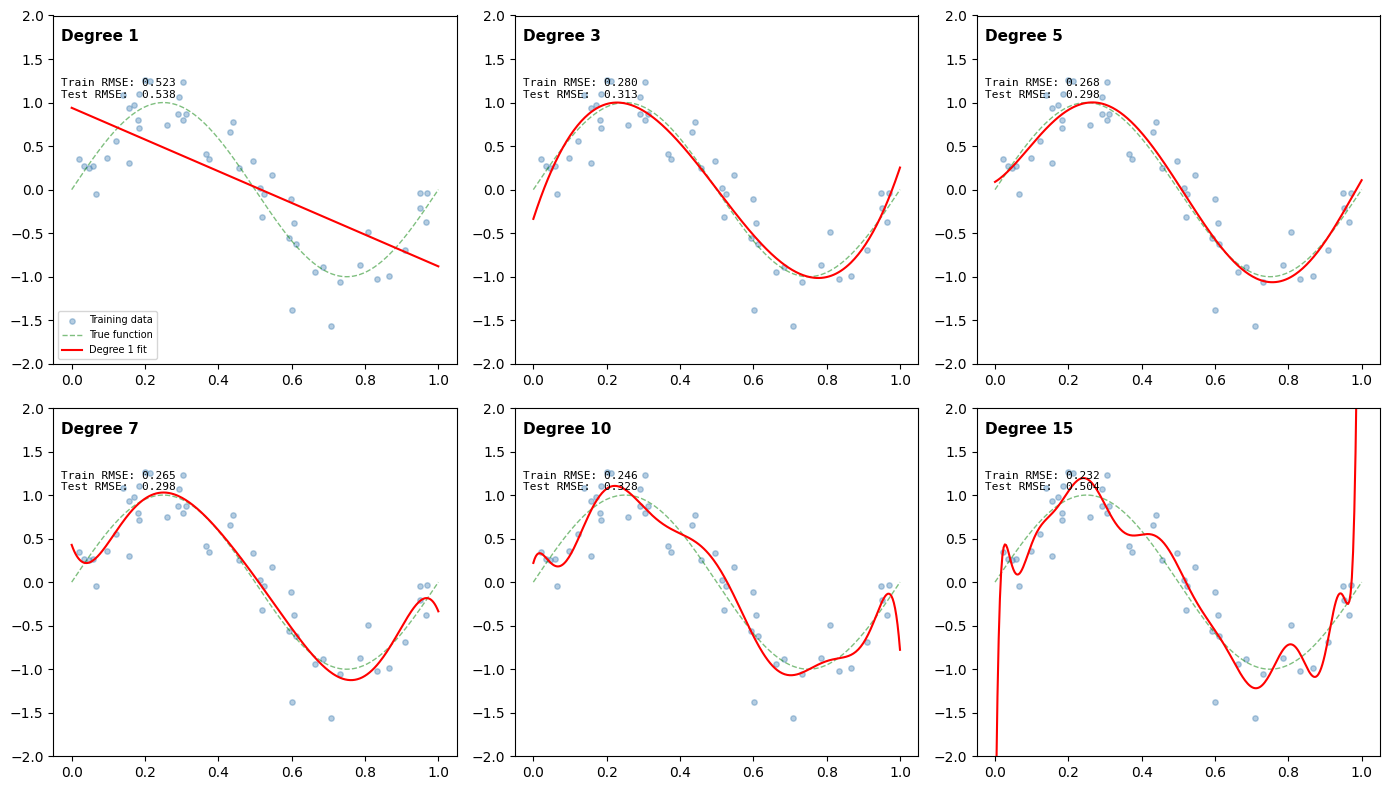

In [40]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

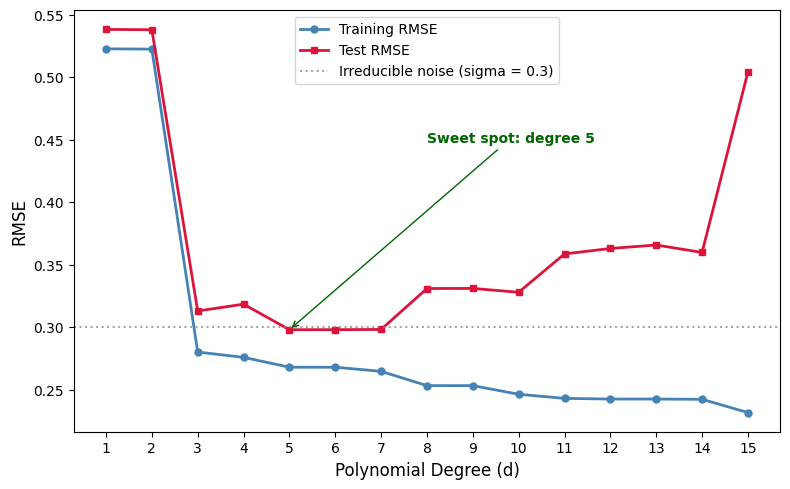

In [41]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [42]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [43]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


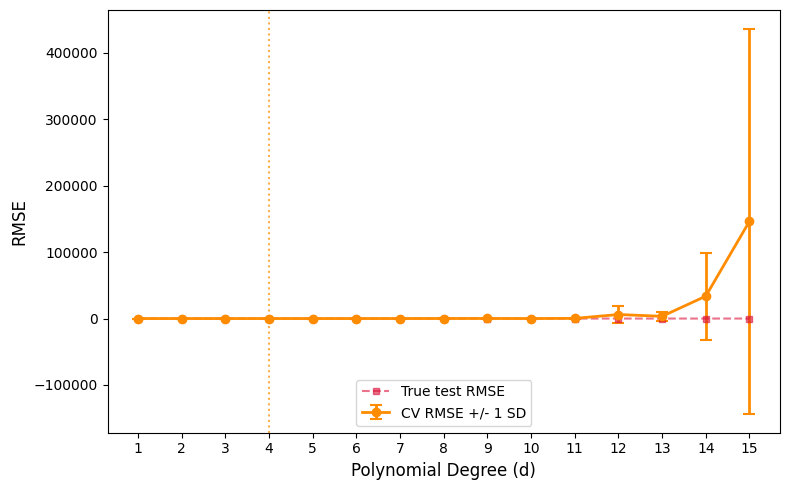

CV-selected degree: 4
True optimal degree: 5


In [44]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [45]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [46]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


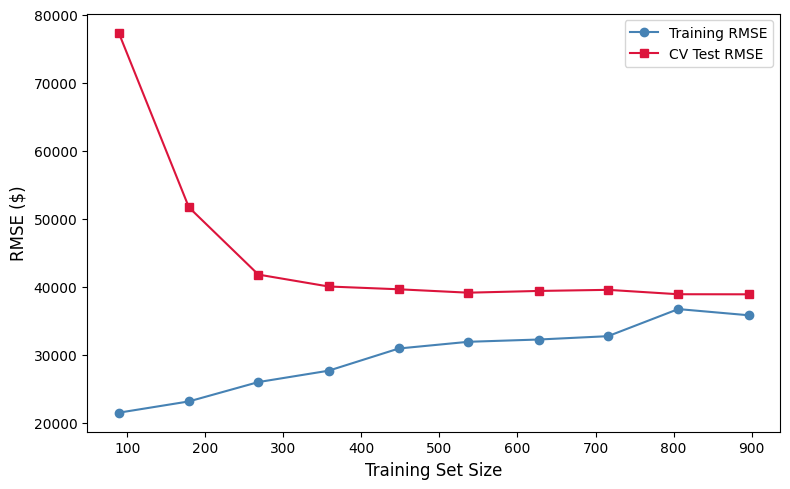

In [47]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    make_pipeline(StandardScaler(), LinearRegression()),
    X_ames, y_ames,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error'
)

train_rmse_lc = np.sqrt(-train_scores).mean(axis=1)
test_rmse_lc = np.sqrt(-test_scores).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_rmse_lc, 'o-', color='steelblue',
        label='Training RMSE')
ax.plot(train_sizes, test_rmse_lc, 's-', color='crimson',
        label='CV Test RMSE')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('RMSE ($)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### AI Expansion

In [48]:
# ═══════════════════════════════════════════════════════════════════════════════
# BIAS-VARIANCE EXPLORER — Interactive Dashboard
# Paste this after your existing Lab 15 cells
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Install / enable ipywidgets for Colab ──────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])

from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display, clear_output
from functools import lru_cache
import matplotlib.gridspec as gridspec

print("✅ Dashboard dependencies ready")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Core math helpers
# ═══════════════════════════════════════════════════════════════════════════════

def true_fn(x):
    return np.sin(2 * np.pi * x)


def make_data(n_train, sigma, seed=42):
    """Reproducible train/test split from the noisy DGP."""
    rng = np.random.default_rng(seed)
    n_total = n_train + 200
    x = rng.uniform(0, 1, n_total)
    y = true_fn(x) + rng.normal(0, sigma, n_total)
    return x[:n_train], y[:n_train], x[n_train:], y[n_train:]


def fit_poly(degree, x_tr, y_tr):
    pipe = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )
    pipe.fit(x_tr.reshape(-1, 1), y_tr)
    return pipe


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ── Complexity curve — cached by (n_train, sigma), instant on degree change ───

@lru_cache(maxsize=64)
def complexity_curve(n_train, sigma, max_deg=15):
    x_tr, y_tr, x_te, y_te = make_data(n_train, sigma)
    tr_rmse, te_rmse = [], []
    for d in range(1, max_deg + 1):
        m = fit_poly(d, x_tr, y_tr)
        tr_rmse.append(rmse(y_tr, m.predict(x_tr.reshape(-1, 1))))
        te_rmse.append(rmse(y_te, m.predict(x_te.reshape(-1, 1))))
    return np.array(tr_rmse), np.array(te_rmse)


# ── Bootstrap bias–variance decomposition — slow once, cached forever ─────────

@lru_cache(maxsize=64)
def bv_decomposition(n_train, sigma, n_boot=100, max_deg=15, seed=7):
    """
    For each degree d, estimates over a dense x-grid:
      Bias²(x) = (E_boot[ŷ(x)] − f(x))²     averaged over x
      Var(x)   = Var_boot[ŷ(x)]               averaged over x

    Sanity check:  Bias² + Var + σ² ≈ MSE_test
    """
    rng    = np.random.default_rng(seed)
    x_grid = np.linspace(0, 1, 300)
    f_grid = true_fn(x_grid)

    x_tr, y_tr, x_te, y_te = make_data(n_train, sigma)

    bias2_arr, var_arr, mse_arr = [], [], []

    for d in range(1, max_deg + 1):
        preds = np.zeros((n_boot, len(x_grid)))

        for b in range(n_boot):
            idx     = rng.integers(0, n_train, size=n_train)   # resample w/ replacement
            m       = fit_poly(d, x_tr[idx], y_tr[idx])
            preds[b] = m.predict(x_grid.reshape(-1, 1))

        mean_pred = preds.mean(axis=0)
        bias2     = np.mean((mean_pred - f_grid) ** 2)
        var       = np.mean(preds.var(axis=0))

        m_full = fit_poly(d, x_tr, y_tr)
        mse    = mean_squared_error(y_te, m_full.predict(x_te.reshape(-1, 1)))

        bias2_arr.append(bias2)
        var_arr.append(var)
        mse_arr.append(mse)

    return {
        'bias2' : np.array(bias2_arr),
        'var'   : np.array(var_arr),
        'mse'   : np.array(mse_arr),
        'sigma2': sigma ** 2,
    }


print("✅ Core math helpers defined")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Plotting helpers (one function per panel)
# ═══════════════════════════════════════════════════════════════════════════════

X_SMOOTH = np.linspace(0, 1, 400)
DEGREES  = np.arange(1, 16)


def plot_fit(ax, degree, n_train, sigma):
    """Panel A — data + true function + fitted polynomial."""
    x_tr, y_tr, _, _ = make_data(n_train, sigma)
    model = fit_poly(degree, x_tr, y_tr)

    ax.scatter(x_tr, y_tr, s=18, color='steelblue', alpha=0.5, zorder=2,
               label=f'Train data (n={n_train})')
    ax.plot(X_SMOOTH, true_fn(X_SMOOTH), 'g--', lw=2,
            label='True: sin(2πx)', zorder=3)
    ax.plot(X_SMOOTH, model.predict(X_SMOOTH.reshape(-1, 1)),
            'r-', lw=2, label=f'Poly degree {degree}', zorder=4)

    ax.set_xlim(0, 1);  ax.set_ylim(-2.8, 2.8)
    ax.set_title(f'Polynomial Fit  (degree = {degree})', fontweight='bold')
    ax.set_xlabel('x');  ax.set_ylabel('y')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_complexity(ax, degree, n_train, sigma):
    """Panel B — train vs test RMSE for all degrees, marker at selected."""
    tr_rmse, te_rmse = complexity_curve(n_train, sigma)

    ax.plot(DEGREES, tr_rmse, 'o-', color='steelblue', lw=2, ms=4,
            label='Train RMSE')
    ax.plot(DEGREES, te_rmse, 's-', color='crimson',   lw=2, ms=4,
            label='Test RMSE')

    ax.axvline(degree, color='darkorange', lw=1.5, linestyle=':', alpha=0.9,
               label=f'Selected degree {degree}')
    ax.plot(degree, tr_rmse[degree - 1], 'o', color='steelblue', ms=9, zorder=5)
    ax.plot(degree, te_rmse[degree - 1], 's', color='crimson',   ms=9, zorder=5)
    ax.axhline(sigma, color='gray', lw=1, linestyle='--', alpha=0.6,
               label=f'σ = {sigma:.2f} (noise floor)')

    ax.set_xlim(0.5, 15.5);  ax.set_xticks(DEGREES)
    ax.set_title('Complexity Curve', fontweight='bold')
    ax.set_xlabel('Polynomial Degree');  ax.set_ylabel('RMSE')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_bv(ax, degree, n_train, sigma):
    """Panel C — bootstrap Bias², Variance, MSE with sanity-check annotation."""
    bv     = bv_decomposition(n_train, sigma)
    sigma2 = bv['sigma2']

    ax.plot(DEGREES, bv['bias2'], 's-', color='mediumpurple', lw=2, ms=4,
            label='Bias²')
    ax.plot(DEGREES, bv['var'],   's-', color='darkorange',   lw=2, ms=4,
            label='Variance')
    ax.plot(DEGREES, bv['mse'],   'o-', color='crimson',      lw=2.5, ms=5,
            label='Test MSE (direct)')
    ax.plot(DEGREES, bv['bias2'] + bv['var'] + sigma2,
            'w:', lw=1.2, alpha=0.6, label='Bias²+Var+σ² (check)')
    ax.axhline(sigma2, color='gray', lw=1, linestyle='--', alpha=0.6,
               label=f'σ² = {sigma2:.3f}')
    ax.axvline(degree, color='darkorange', lw=1.5, linestyle=':', alpha=0.85)

    # Sanity-check annotation at the selected degree
    d_idx  = degree - 1
    approx = bv['bias2'][d_idx] + bv['var'][d_idx] + sigma2
    direct = bv['mse'][d_idx]
    gap    = abs(approx - direct)
    color  = 'green' if gap < 0.05 else 'goldenrod'

    ax.annotate(
        f"d={degree}\nB²+V+σ²={approx:.3f}\nMSE={direct:.3f}\n|gap|={gap:.3f}",
        xy=(degree, direct),
        xytext=(min(degree + 1.2, 13), direct + max(0.03, direct * 0.3)),
        fontsize=7.5, color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=0.9),
    )

    ax.set_xlim(0.5, 15.5);  ax.set_xticks(DEGREES)
    ax.set_title('Bootstrap Bias–Variance Decomposition  (100 resamples / degree)',
                 fontweight='bold')
    ax.set_xlabel('Polynomial Degree');  ax.set_ylabel('MSE units')
    ax.legend(loc='upper center', ncol=3, fontsize=8)
    ax.grid(True, alpha=0.3)


print("✅ Plotting helpers defined")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Pre-warm bootstrap cache at defaults (runs once, ~5 s)
# ═══════════════════════════════════════════════════════════════════════════════

print("Pre-warming bootstrap cache for default params (n=60, σ=0.3)…")
_ = bv_decomposition(60, 0.3)
print("✅ Cache warm — degree slider will now be instant")


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Interactive dashboard
# ═══════════════════════════════════════════════════════════════════════════════

# ── Sliders ───────────────────────────────────────────────────────────────────
slider_deg = widgets.IntSlider(
    value=3, min=1, max=15, step=1,
    description='Degree',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='380px'),
    continuous_update=False,     # fires on mouse-up only → stays snappy
)
slider_sig = widgets.FloatSlider(
    value=0.3, min=0.1, max=1.0, step=0.05,
    description='σ (noise)',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='380px'),
    continuous_update=False,
    readout_format='.2f',
)
slider_n = widgets.IntSlider(
    value=60, min=20, max=200, step=10,
    description='N train',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='380px'),
    continuous_update=False,
)

# ── Status indicator ──────────────────────────────────────────────────────────
status = widgets.HTML(
    value='<span style="color:green; font-family:monospace; font-size:12px">● ready</span>'
)

# ── Output widget (swapped atomically on each redraw) ─────────────────────────
out = widgets.Output()


def draw(degree, sigma, n_train):
    sigma = round(sigma, 10)     # ensure exact float for lru_cache key

    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            height_ratios=[1, 0.9],
                            hspace=0.4, wspace=0.3)
    ax_fit  = fig.add_subplot(gs[0, 0])
    ax_cmpl = fig.add_subplot(gs[0, 1])
    ax_bv   = fig.add_subplot(gs[1, :])

    plot_fit(ax_fit,       degree, n_train, sigma)
    plot_complexity(ax_cmpl, degree, n_train, sigma)
    plot_bv(ax_bv,         degree, n_train, sigma)

    fig.suptitle(
        f'Bias–Variance Explorer  ·  degree={degree}  σ={sigma:.2f}  n={n_train}',
        fontsize=13, fontweight='bold', y=1.01,
    )

    with out:
        clear_output(wait=True)
        plt.show()
    plt.close(fig)


def on_change(change):
    status.value = '<span style="color:orange; font-family:monospace; font-size:12px">⟳ updating…</span>'
    draw(slider_deg.value, slider_sig.value, slider_n.value)
    status.value = '<span style="color:green; font-family:monospace; font-size:12px">● ready</span>'


slider_deg.observe(on_change, names='value')
slider_sig.observe(on_change, names='value')
slider_n.observe(on_change,   names='value')

# ── Assemble and display ──────────────────────────────────────────────────────
header = widgets.HTML(
    '<h3 style="font-family:monospace; margin-bottom:2px">'
    '📈 Bias–Variance Tradeoff Explorer</h3>'
    '<p style="font-family:monospace; font-size:11px; color:gray; margin-top:0">'
    'y = sin(2πx) + ε &nbsp;·&nbsp; polynomial regression '
    '&nbsp;·&nbsp; 100 bootstrap resamples per degree</p>'
)
controls = widgets.VBox([
    header,
    widgets.HBox([slider_deg, slider_sig, slider_n]),
    status,
], layout=widgets.Layout(margin='0 0 10px 0'))

display(widgets.VBox([controls, out]))
draw(slider_deg.value, slider_sig.value, slider_n.value)   # initial render

✅ Dashboard dependencies ready
✅ Core math helpers defined
✅ Plotting helpers defined
Pre-warming bootstrap cache for default params (n=60, σ=0.3)…
✅ Cache warm — degree slider will now be instant
